In [1]:
from pathlib import Path
import xarray as xr
import torch
import torch.nn.functional
from climanet.st_encoder_decoder import SpatioTemporalModel
from climanet.utils import set_seed, configure_compute_resources, plot_results, plot_histograms, plot_loss, data_preparation, read_st_data, lsm_sst2wv
from climanet.train import train_monthly_model, TrainConfig
from climanet.predict import predict_monthly_var, PredictionConfig
from climanet.dataset import STDataset, DataLoaderConfig

from tbparse import SummaryReader
import matplotlib.pyplot as plt

## Read data

In [30]:
# without diurnal cycle
data_folder = Path("../eso4clima/watervapor")
run_dir = Path("./runs_daily").resolve()

var_name = "prw"

# 1 month train, 1 month validation and test
daily_data = xr.open_mfdataset(data_folder / f"202001_day_ERA5_masked_{var_name}.nc")
daily_data_validation = xr.open_mfdataset(data_folder / f"202101_day_ERA5_masked_{var_name}.nc")
daily_data_test = xr.open_mfdataset(data_folder / f"202201_day_ERA5_masked_{var_name}.nc")

monthly_data = xr.open_mfdataset(data_folder / f"202001_mon_ERA5_full_{var_name}.nc")
monthly_data_validation = xr.open_mfdataset(data_folder / f"202101_mon_ERA5_full_{var_name}.nc")
monthly_data_test = xr.open_mfdataset(data_folder / f"202201_mon_ERA5_full_{var_name}.nc")

# Make land-sea mask for watervapor from sst mask
file_name = data_folder / "era5_lsm_bool.nc"  # downloded from era5 and regridded using the function `regrid_to_boundary_centered_grid`
lsm_mask_sst = xr.open_dataset(file_name)
lsm_mask = lsm_sst2wv(lsm_mask_sst)

In [3]:
# sort in lat dimension to make it ascending
daily_data = daily_data.sortby("lat")
daily_data_validation = daily_data_validation.sortby("lat")
daily_data_test = daily_data_test.sortby("lat")

monthly_data = monthly_data.sortby("lat")
monthly_data_validation = monthly_data_validation.sortby("lat")
monthly_data_test = monthly_data_test.sortby("lat")

## Subset data (for fast example)

In [4]:
# coordinates of subset
lon_subset = slice(-10, 10)  # one lon -179.9 is nan, check data
lat_subset = slice(-10, 10)

daily_subset = daily_data.sel(lon=lon_subset, lat=lat_subset)
monthly_subset = monthly_data.sel(lon=lon_subset, lat=lat_subset)
lsm_subset = lsm_mask.sel(lon=lon_subset, lat=lat_subset)  # True=Land

daily_validation_subset = daily_data_validation.sel(lon=lon_subset, lat=lat_subset)
monthly_validation_subset = monthly_data_validation.sel(lon=lon_subset, lat=lat_subset)

daily_test_subset = daily_data_test.sel(lon=lon_subset, lat=lat_subset)
monthly_test_subset = monthly_data_test.sel(lon=lon_subset, lat=lat_subset)

print(daily_subset[var_name].shape, monthly_subset[var_name].shape)  # (time, lat, lon)

(31, 40, 40) (1, 40, 40)


## Training workflow

### Build the model

In [5]:
# create the model (small)
set_seed()

In [6]:
patch_size = (1, 4, 4)
model = SpatioTemporalModel(patch_size=patch_size, embed_dim=64, dropout=0.1, hidden=64)

In [7]:
# Device and resources
device = "cpu"
compute_threads = 4
dataloader_num_workers = 0
model = configure_compute_resources(model, device=device, compute_threads=compute_threads, dataloader_num_workers=dataloader_num_workers)

### Build the datasets

#### Prepare the train data

In [8]:
# this should be done once
data_dir = Path(f"{run_dir}/data_train")
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_subset[var_name], monthly_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [9]:
# read data 
data_dir = f"{run_dir}/data_train"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [10]:
# create dataset config
num_subsets = (10, 10)
spatial_crop_size = (patch_size[1]*num_subsets[0], patch_size[2]*num_subsets[1])
stride = (spatial_crop_size[0] // 5, spatial_crop_size[1] // 5)  # for data agumentation

dataset_train = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    model_patch_size=patch_size,
    crop_size=(1, *spatial_crop_size),   # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=False,   # set it to true when data is large
)
print(len(dataset_train))

Creating dataset:
Crop grid (m x i x j): 1 x 1 x 1 = 1 data crops
Overlap: 32 pixels (height), 32 pixels (width)
1


#### Prepare validation data

In [11]:
# this should be done once
data_dir = f"{run_dir}/data_validation"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_validation_subset[var_name], monthly_validation_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [12]:
# read data 
data_dir = f"{run_dir}/data_validation"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [13]:
num_subsets = (10, 10)
spatial_crop_size = (patch_size[1]*num_subsets[0], patch_size[2]*num_subsets[1])
stride = (spatial_crop_size[0] // 5, spatial_crop_size[1] // 5)  # for data agumentation

dataset_validation = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    model_patch_size=patch_size,
    crop_size=(1, *spatial_crop_size),   # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=False,  # set it to true when data is large
)
print(len(dataset_validation))

Creating dataset:
Crop grid (m x i x j): 1 x 1 x 1 = 1 data crops
Overlap: 32 pixels (height), 32 pixels (width)
1


In [14]:
# create dataloader config
dataloader_config = DataLoaderConfig(
    batch_size=10,
    shuffle=True,
    num_workers= dataloader_num_workers,
    pin_memory=False,
    persistent_workers=False,  # set it to true when num_workers >0 and lazy data
    device=device,
    multiprocessing_context=None, # set it to "spawn" when num_workers >0 and lazy data
)
dataloader_config

DataLoaderConfig(batch_size=10, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False, device='cpu', multiprocessing_context=None)

In [15]:
# create training config
training_config = TrainConfig(
    calculate_residuals=True,
    num_epoch=100,
    patience=10,
    accumulation_steps=2,
    optimizer_lr=1e-3,
    device=device,
    verbose=True,
    verbose_epoch_interval=20,
    tune_checkpoint=False,
    store_model=True,
)
training_config

TrainConfig(calculate_residuals=True, num_epoch=100, patience=10, accumulation_steps=2, optimizer_lr=0.001, optimizer_weight_decay=0.01, scheduler_lr_factor=0.1, scheduler_min_lr=1e-05, device='cpu', verbose=True, verbose_epoch_interval=20, tune_checkpoint=False, store_model=True, store_logs=True)

### Start training loop

In [16]:
dataset_train.model_patch_size

(1, 4, 4)

In [17]:
%%time
# verbose is True
trained_model = train_monthly_model(
    model=model,
    dataset_train=dataset_train,
    dataloader_config=dataloader_config,
    training_config=training_config,
    dataset_validation=dataset_validation,  # here validation dataset is used to improve model generalization
    run_dir=run_dir,
)

Epoch 0: gap between train and val loss: 0.044098
Epoch 0: best_loss = 0.298102
Epoch 20: gap between train and val loss: -0.008917
Epoch 20: best_loss = 0.092625
Epoch 40: gap between train and val loss: -0.013420
Epoch 40: best_loss = 0.079654
Early stopping triggered at epoch 47. Best loss: 0.079654
Training complete. Best loss: 0.079654
Model saved to /home/oku/Developments/ESO4Clima/ClimaNet/notebooks/watervapor/runs_daily/best_model.pth
CPU times: user 21.8 s, sys: 378 ms, total: 22.2 s
Wall time: 8.48 s


## Inspect results and compare

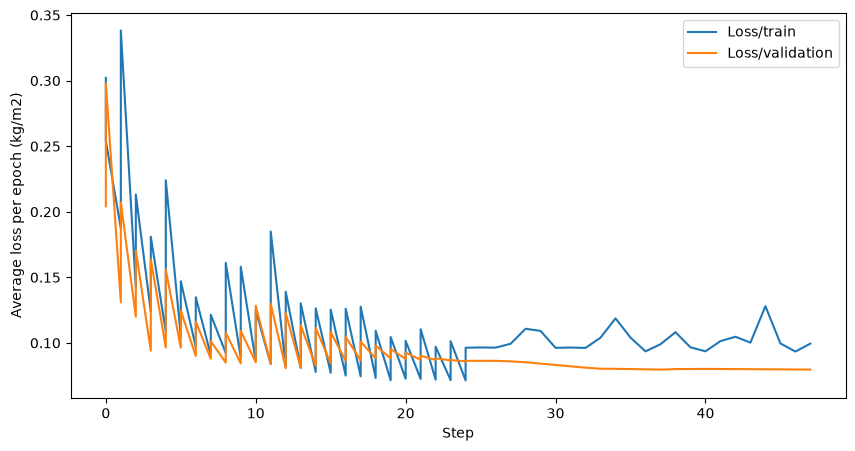

In [18]:
plot_loss(run_dir, list_loss_var=["Loss/train", "Loss/validation"], unit="kg/m2")

#### Prepare the test data

In [19]:
# this hsould be done once
data_dir = f"{run_dir}/data_test"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_test_subset[var_name], monthly_test_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [20]:
# read data 
data_dir = f"{run_dir}/data_test"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [21]:
spatial_patch_size = monthly_da.shape[1:]  # the whole dataset 

dataset_test = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    model_patch_size=patch_size,
    crop_size=(1, *spatial_crop_size), 
    stride=None,  # no stride in inference
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=False,
)
print(len(dataset_test))

Creating dataset:
Crop grid (m x i x j): 1 x 1 x 1 = 1 data crops
Overlap: 0 pixels (height), 0 pixels (width)
1


In [22]:
# create dataloader config
dataloader_config = DataLoaderConfig(
    batch_size=10,
    shuffle=False,  # no shuffling in inference
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
    device=device,
    multiprocessing_context=None, # keep this when num_workers >0 and lazy data
)
dataloader_config

DataLoaderConfig(batch_size=10, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False, device='cpu', multiprocessing_context=None)

In [23]:
# create prediction config
prediction_config = PredictionConfig(
    calculate_residuals=True,
    return_numpy=True,
    save_predictions=True,
    return_loss=False,
    device=device,
    verbose=True,
)

In [24]:
# inference on test data, verbose is True
predictions = predict_monthly_var(
    model=f"{run_dir}/best_model.pth",
    dataset=dataset_test,  
    dataloader_config=dataloader_config,
    prediction_config=prediction_config,
    run_dir=run_dir,
)

Processed batch 1/1, with loss: 0.0850
Average loss over all batches: 0.0850


In [25]:
predictions_res = xr.open_dataset(f"{run_dir}/202201_{var_name}_prediction_residual.nc")

In [26]:
# add to monthly average
input_data_averaged = daily_test_subset.resample({"time": "MS"}).mean(skipna=True)
input_data_averaged["time"] = monthly_test_subset["time"]
predictions = input_data_averaged[var_name] + predictions_res[var_name]

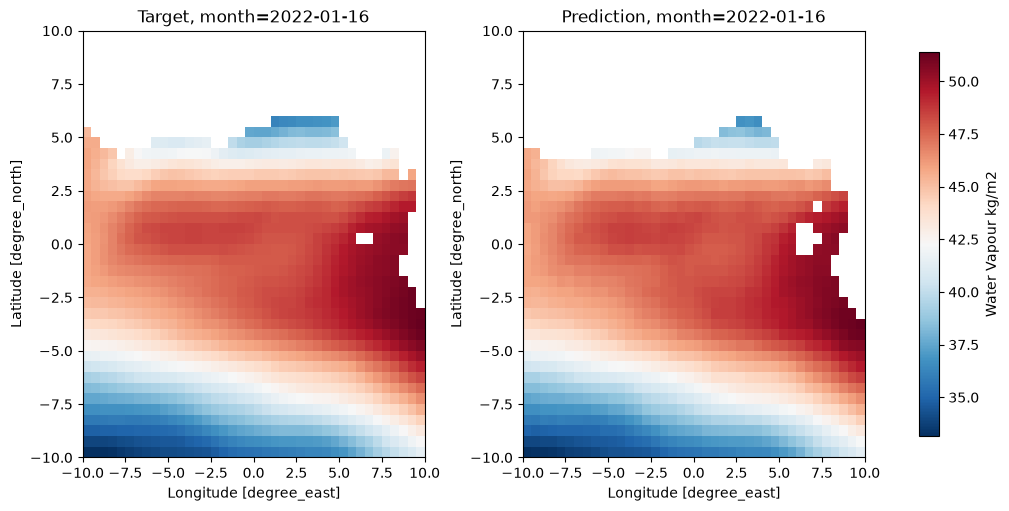

In [27]:
ocean = ~lsm_subset["lsm"].values
masked_target = monthly_test_subset[var_name].where(ocean)
masked_pred = predictions.where(ocean)
plot_results(masked_target, masked_pred, label="Water Vapour kg/m2", title=("Target", "Prediction"))

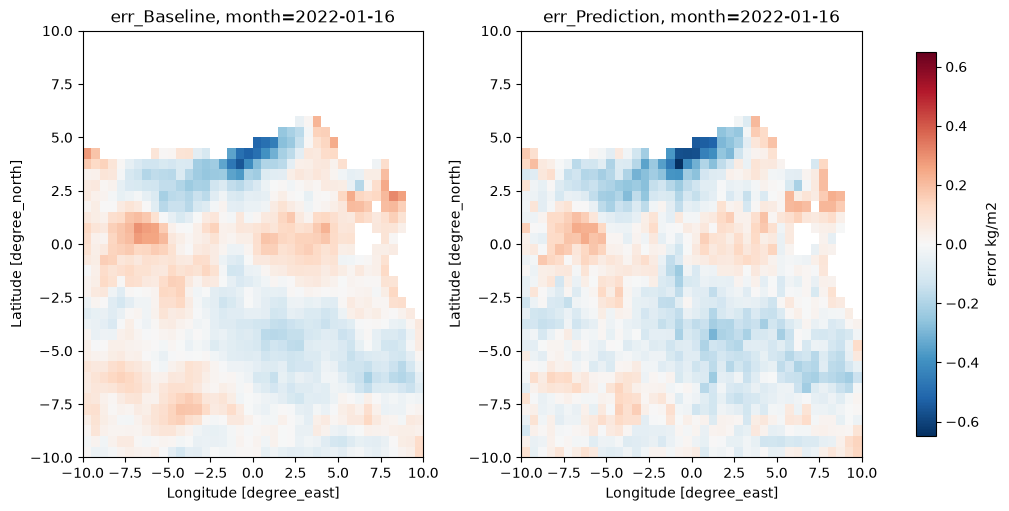

In [28]:
err_baseline = (monthly_test_subset[var_name] - input_data_averaged[var_name])   # M - mean(D)
err_predictions = (monthly_test_subset[var_name] - predictions)  # M - M_hat

ocean = ~lsm_subset["lsm"].values
masked_err_baseline = err_baseline.where(ocean)
masked_err_predictions = err_predictions.where(ocean) 

plot_results(masked_err_baseline, masked_err_predictions, label="error kg/m2", title=("err_Baseline", "err_Prediction"), error=True)

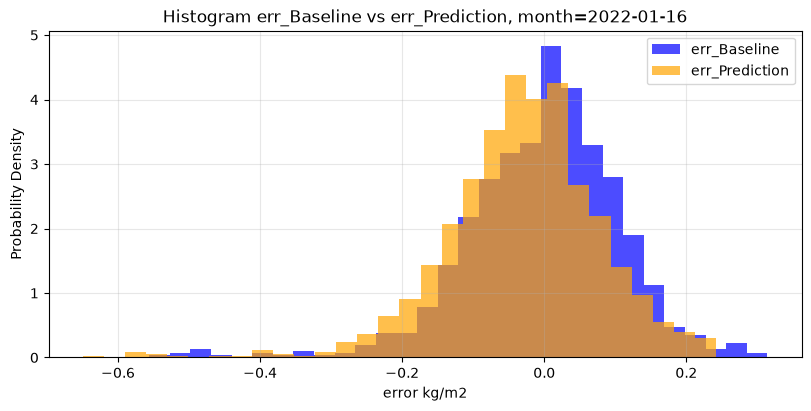

In [29]:
plot_histograms(masked_err_baseline, masked_err_predictions, label="error kg/m2", legend_labels=("err_Baseline", "err_Prediction"))